In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
lookback = 60
forecast_horizon = 7

X = []
y = []

for i in range(lookback, len(scaled_data) - forecast_horizon + 1):
    X.append(scaled_data[i-lookback:i])
    y.append(scaled_data[i:i+forecast_horizon, 0])  # 7 future gold prices

import numpy as np
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

In [ ]:
lookback = 60
forecast_horizon = 7

X = []
y = []

for i in range(lookback, len(scaled_data) - forecast_horizon + 1):
    X.append(scaled_data[i-lookback:i])
    y.append(scaled_data[i:i+forecast_horizon, 0])  # 7 future gold prices

import numpy as np
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

In [ ]:
features = df.drop(columns=["Date"])
scaled_data = scaler.transform(features)

import joblib
scaler = joblib.load("../data/processed/scaler.save")
print("Scaler loaded")

In [1]:
import joblib
scaler = joblib.load("../data/processed/scaler.save")
print("Scaler loaded")

Scaler loaded


In [2]:
features = df.drop(columns=["Date"])
print("Features ready")

NameError: name 'df' is not defined

In [3]:
import pandas as pd
import numpy as np
import joblib

In [4]:
df = pd.read_csv("../data/processed/gold_lstm_features_engineered.csv")

print(df.shape)

(2016, 8)


In [5]:
scaler = joblib.load("../data/processed/scaler.save")
print("Scaler loaded")

Scaler loaded


In [6]:
scaled_data = scaler.transform(features)
print("Scaling done")

NameError: name 'features' is not defined

In [7]:
features = df.drop(columns=["Date"])
print("Features ready:", features.shape)

Features ready: (2016, 7)


In [8]:
scaled_data = scaler.transform(features)
print("Scaling done:", scaled_data.shape)

Scaling done: (2016, 7)


In [9]:
lookback = 60
forecast_horizon = 7

X = []
y = []

for i in range(lookback, len(scaled_data) - forecast_horizon + 1):
    X.append(scaled_data[i-lookback:i])
    y.append(scaled_data[i:i+forecast_horizon, 0])  # 7 future gold prices

import numpy as np
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1950, 60, 7)
y shape: (1950, 7)


In [10]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1560, 60, 7) (1560, 7)
Test: (390, 60, 7) (390, 7)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(60, 7)))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(7))  # 7 outputs

model.compile(optimizer='adam', loss='mse')

c:\Users\iamme\karat\karat\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=(60, 7)))   # 👈 Define input here

model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(7))   # 7 outputs

model.compile(optimizer='adam', loss='mse')

In [17]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X shape: (1950, 60, 7)
y shape: (1950, 7)
X_train: (1560, 60, 7)
y_train: (1560, 7)
X_test: (390, 60, 7)
y_test: (390, 7)


In [18]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,          # reduce first for testing
    batch_size=32,
    verbose=1           # must be 1
)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0095 - val_loss: 0.0372
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0020 - val_loss: 0.0266
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0016 - val_loss: 0.0200
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0013 - val_loss: 0.0219
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0012 - val_loss: 0.0156
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0011 - val_loss: 0.0145
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0011 - val_loss: 0.0118
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 8.9014e-04 - val_loss: 0.0138
Epoch 9/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 8.3843e-04 - val_loss: 0.0113
Epoch 10/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 8.3352e-04 - val_loss: 0.0114
Epoch 11/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 6.6744e-04 - val_loss: 0.0144
Epoch 12/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/

In [19]:
import numpy as np

y_pred = model.predict(X_test)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE:", mape)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
MAPE: 10.6100747621718


In [20]:
model = Sequential()

model.add(Input(shape=(60, 7)))

model.add(LSTM(96, return_sequences=True))
model.add(Dropout(0.25))

model.add(LSTM(48))
model.add(Dropout(0.25))

model.add(Dense(7))

model.compile(optimizer='adam', loss='mse')

In [21]:
model = Sequential()

model.add(Input(shape=(60, 7)))

model.add(LSTM(96, return_sequences=True))
model.add(Dropout(0.25))

model.add(LSTM(48))
model.add(Dropout(0.25))

model.add(Dense(7))

model.compile(optimizer='adam', loss='mse')

In [22]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Create empty arrays with same feature count
y_pred_full = np.zeros((y_pred.shape[0], 7))
y_test_full = np.zeros((y_test.shape[0], 7))

# Put gold predictions in first column (index 0)
y_pred_full[:, 0] = y_pred[:, 0]
y_test_full[:, 0] = y_test[:, 0]

# Inverse transform
y_pred_inverse = scaler.inverse_transform(y_pred_full)[:, 0]
y_test_inverse = scaler.inverse_transform(y_test_full)[:, 0]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_inverse, y_pred_inverse))

print("RMSE:", rmse)

RMSE: 8891.297008336782


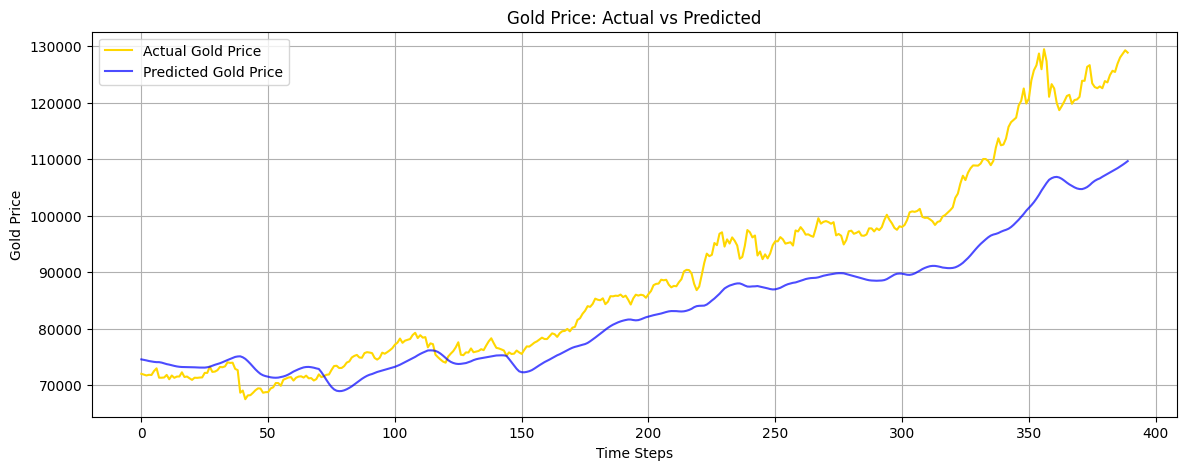

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_test_inverse, label='Actual Gold Price', color='gold')
plt.plot(y_pred_inverse, label='Predicted Gold Price', color='blue', alpha=0.7)
plt.title('Gold Price: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
mape = np.mean(np.abs((y_test_inverse - y_pred_inverse) / y_test_inverse)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 8891.30
MAE:  6932.20
MAPE: 6.99%


In [25]:
# Did the model predict up/down correctly?
actual_dir = np.diff(y_test_inverse) > 0
pred_dir = np.diff(y_pred_inverse) > 0

directional_accuracy = np.mean(actual_dir == pred_dir) * 100
print(f"Directional Accuracy: {directional_accuracy:.2f}%")

Directional Accuracy: 51.41%


In [26]:
# Before creating sequences, transform target
df['Gold_Return'] = df['Gold_Close'].pct_change()
# Train on returns → convert back to price after prediction

In [27]:
import pandas as pd
import numpy as np

# Save original prices for later reconstruction
original_prices = df['Gold_Close'].values.copy()

# Create return-based features
df['Gold_Return'] = df['Gold_Close'].pct_change()
df['USD_Return'] = df['USD_Close'].pct_change()
df['Gold_MA7_Return'] = df['Gold_MA7'].pct_change()
df['Gold_MA30_Return'] = df['Gold_MA30'].pct_change()
df['USD_MA7_Return'] = df['USD_MA7'].pct_change()

# Drop NaNs
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Shape after returns:", df.shape)

KeyError: 'Gold_MA7'

In [28]:
print(df.columns.tolist())

['Date', 'Gold_Close', 'USD_Close', 'avg_sentiment', 'news_count', 'Gold_7day_MA', 'Gold_30day_MA', 'USD_7day_MA', 'Gold_Return', 'USD_Return']


In [29]:
import pandas as pd
import numpy as np

# Save original prices for later reconstruction
original_prices = df['Gold_Close'].values.copy()

# Create return-based features (using correct column names)
df['Gold_Return'] = df['Gold_Close'].pct_change()
df['USD_Return'] = df['USD_Close'].pct_change()
df['Gold_MA7_Return'] = df['Gold_7day_MA'].pct_change()
df['Gold_MA30_Return'] = df['Gold_30day_MA'].pct_change()
df['USD_MA7_Return'] = df['USD_7day_MA'].pct_change()

# Drop NaNs
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Shape after returns:", df.shape)
print("Columns:", df.columns.tolist())

Shape after returns: (2015, 13)
Columns: ['Date', 'Gold_Close', 'USD_Close', 'avg_sentiment', 'news_count', 'Gold_7day_MA', 'Gold_30day_MA', 'USD_7day_MA', 'Gold_Return', 'USD_Return', 'Gold_MA7_Return', 'Gold_MA30_Return', 'USD_MA7_Return']


In [30]:
from sklearn.preprocessing import MinMaxScaler

features = ['Gold_Return', 'USD_Return', 'Gold_MA7_Return', 
            'Gold_MA30_Return', 'USD_MA7_Return', 'avg_sentiment', 'news_count']

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[features])

LOOKBACK = 60
HORIZON = 7

X, y = [], []
for i in range(LOOKBACK, len(scaled) - HORIZON):
    X.append(scaled[i-LOOKBACK:i])
    y.append(scaled[i:i+HORIZON, 0])  # Gold_Return is index 0

X, y = np.array(X), np.array(y)
print("X:", X.shape, "y:", y.shape)

X: (1948, 60, 7) y: (1948, 7)


In [31]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Save corresponding actual prices for reconstruction
prices_test = original_prices[LOOKBACK + split + 1 : LOOKBACK + split + 1 + len(y_test) + HORIZON]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1558, 60, 7) Test: (390, 60, 7)


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(96, return_sequences=True, input_shape=(LOOKBACK, len(features))),
    Dropout(0.25),
    LSTM(48),
    Dropout(0.25),
    Dense(HORIZON)
])

model.compile(optimizer='adam', loss='mse')
es = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                    validation_split=0.1, callbacks=[es], verbose=1)

Epoch 1/100


c:\Users\iamme\karat\karat\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0879 - val_loss: 0.0091
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0320 - val_loss: 0.0081
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0269 - val_loss: 0.0065
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0241 - val_loss: 0.0069
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0210 - val_loss: 0.0081
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0198 - val_loss: 0.0064
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0185 - val_loss: 0.0075
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0176 - val_loss: 0.0084
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0170 - val_loss: 0.0061
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0162 - val_loss: 0.0062
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0154 - val_loss: 0.0066
Epoch 12/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
RMSE: 0.0101
MAE:  0.0072
MAPE: 40972.92%
Directional Accuracy: 50.09%


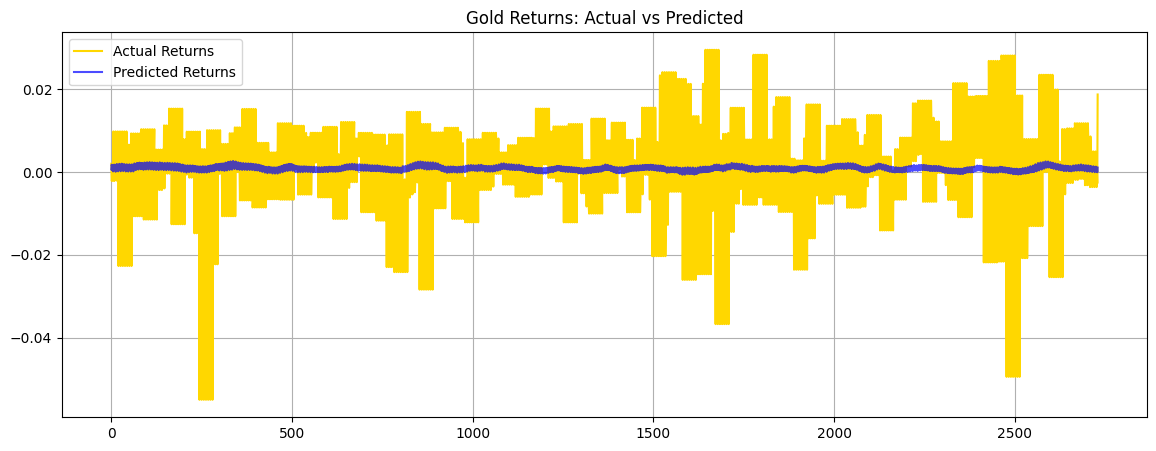

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)

# Inverse transform returns
def inverse_returns(pred_scaled, scaler, n_features=7):
    full = np.zeros((len(pred_scaled), n_features))
    full[:, 0] = pred_scaled
    return scaler.inverse_transform(full)[:, 0]

y_pred_inv = np.array([inverse_returns(y_pred[:, i], scaler) for i in range(HORIZON)]).T
y_test_inv = np.array([inverse_returns(y_test[:, i], scaler) for i in range(HORIZON)]).T

# Flatten for metrics
y_pred_flat = y_pred_inv.flatten()
y_test_flat = y_test_inv.flatten()

rmse = np.sqrt(np.mean((y_pred_flat - y_test_flat)**2))
mae = mean_absolute_error(y_test_flat, y_pred_flat)
mape = np.mean(np.abs((y_test_flat - y_pred_flat) / (y_test_flat + 1e-8))) * 100
dir_acc = np.mean((np.diff(y_test_flat) > 0) == (np.diff(y_pred_flat) > 0)) * 100

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"Directional Accuracy: {dir_acc:.2f}%")

# Plot
plt.figure(figsize=(14,5))
plt.plot(y_test_flat, label='Actual Returns', color='gold')
plt.plot(y_pred_flat, label='Predicted Returns', color='blue', alpha=0.7)
plt.title('Gold Returns: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

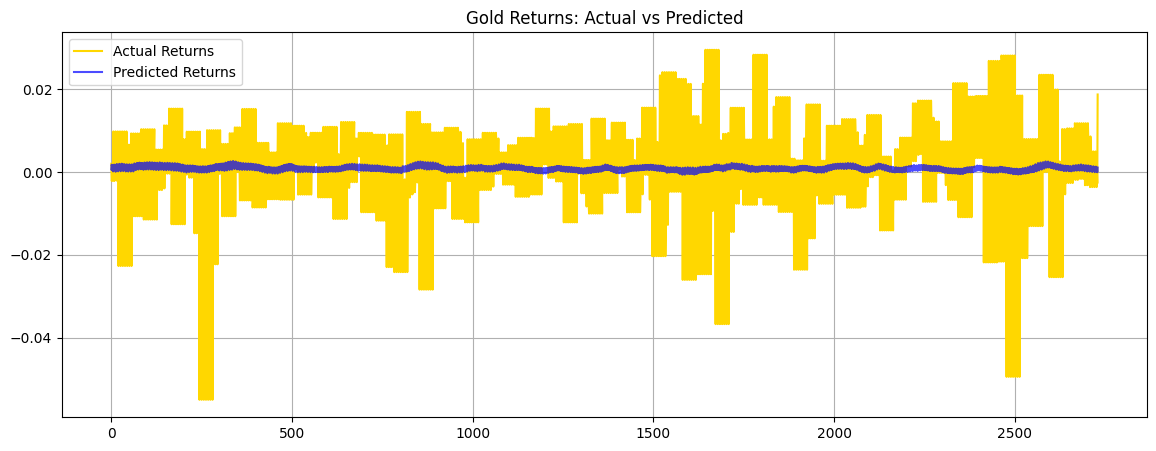

In [34]:
plt.figure(figsize=(14,5))
plt.plot(y_test_flat, label='Actual Returns', color='gold')
plt.plot(y_pred_flat, label='Predicted Returns', color='blue', alpha=0.7)
plt.title('Gold Returns: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
# Start fresh from your original df
# Use price difference instead of % return
df2 = df[['Date', 'Gold_Close', 'USD_Close', 'avg_sentiment', 
          'news_count', 'Gold_7day_MA', 'Gold_30day_MA', 'USD_7day_MA']].copy()

df2['Gold_Diff'] = df2['Gold_Close'].diff()
df2['USD_Diff'] = df2['USD_Close'].diff()

df2.dropna(inplace=True)
df2.reset_index(drop=True, inplace=True)

# Store last known price for reconstruction
last_prices = df2['Gold_Close'].values

features2 = ['Gold_Diff', 'USD_Diff', 'Gold_7day_MA', 
             'Gold_30day_MA', 'USD_7day_MA', 'avg_sentiment', 'news_count']

from sklearn.preprocessing import MinMaxScaler
scaler2 = MinMaxScaler()
scaled2 = scaler2.fit_transform(df2[features2])

LOOKBACK = 60
HORIZON = 7

X2, y2 = [], []
for i in range(LOOKBACK, len(scaled2) - HORIZON):
    X2.append(scaled2[i-LOOKBACK:i])
    y2.append(scaled2[i:i+HORIZON, 0])  # Gold_Diff index 0

X2, y2 = np.array(X2), np.array(y2)
print("X:", X2.shape, "y:", y2.shape)

X: (1947, 60, 7) y: (1947, 7)


In [36]:
split = int(len(X2) * 0.8)
X_train2, X_test2 = X2[:split], X2[split:]
y_train2, y_test2 = y2[:split], y2[split:]

# Save actual prices aligned to test set
prices_test2 = last_prices[LOOKBACK + split: LOOKBACK + split + len(y_test2) + HORIZON]

print("Train:", X_train2.shape, "Test:", X_test2.shape)

Train: (1557, 60, 7) Test: (390, 60, 7)


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model2 = Sequential([
    LSTM(96, return_sequences=True, input_shape=(LOOKBACK, 7)),
    Dropout(0.25),
    LSTM(48),
    Dropout(0.25),
    Dense(HORIZON)
])

model2.compile(optimizer='adam', loss='mse')
es2 = EarlyStopping(patience=10, restore_best_weights=True)

history2 = model2.fit(X_train2, y_train2, epochs=100, batch_size=32,
                      validation_split=0.1, callbacks=[es2], verbose=1)

Epoch 1/100


c:\Users\iamme\karat\karat\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0657 - val_loss: 0.0034
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0174 - val_loss: 0.0036
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0150 - val_loss: 0.0025
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0127 - val_loss: 0.0034
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0110 - val_loss: 0.0025
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0101 - val_loss: 0.0021
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0091 - val_loss: 0.0044
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0085 - val_loss: 0.0027
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0081 - val_loss: 0.0021
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0073 - val_loss: 0.0024
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0069 - val_loss: 0.0026
Epoch 12/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

y_pred2 = model2.predict(X_test2)

# Inverse transform differences
def inverse_diff(pred_scaled, scaler2, n_features=7):
    full = np.zeros((len(pred_scaled), n_features))
    full[:, 0] = pred_scaled
    return scaler2.inverse_transform(full)[:, 0]

y_pred_diff = np.array([inverse_diff(y_pred2[:, i], scaler2) for i in range(HORIZON)]).T
y_test_diff = np.array([inverse_diff(y_test2[:, i], scaler2) for i in range(HORIZON)]).T

# Reconstruct actual prices from differences
start_prices = last_prices[LOOKBACK + split: LOOKBACK + split + len(y_test2)]

y_pred_price

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


NameError: name 'y_pred_price' is not defined

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
RMSE: 2084.88
MAE:  1443.27
MAPE: 1.54%
Directional Accuracy: 52.44%


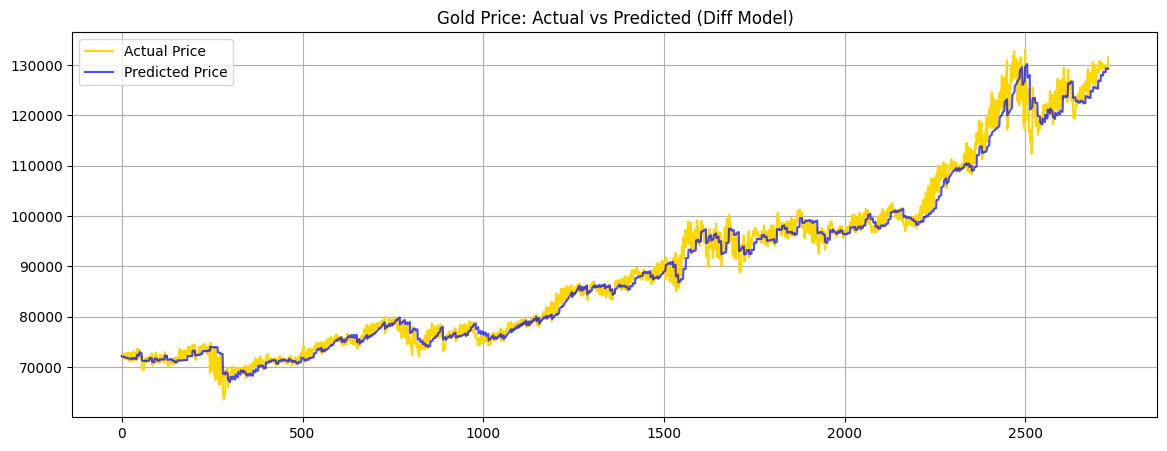

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

y_pred2 = model2.predict(X_test2)

# Inverse transform differences
def inverse_diff(pred_scaled, scaler2, n_features=7):
    full = np.zeros((len(pred_scaled), n_features))
    full[:, 0] = pred_scaled
    return scaler2.inverse_transform(full)[:, 0]

y_pred_diff = np.array([inverse_diff(y_pred2[:, i], scaler2) for i in range(HORIZON)]).T
y_test_diff = np.array([inverse_diff(y_test2[:, i], scaler2) for i in range(HORIZON)]).T

# Reconstruct actual prices from differences
start_prices = last_prices[LOOKBACK + split: LOOKBACK + split + len(y_test2)]

y_pred_price = np.cumsum(y_pred_diff, axis=1) + start_prices.reshape(-1, 1)
y_test_price = np.cumsum(y_test_diff, axis=1) + start_prices.reshape(-1, 1)

# Flatten
y_pred_flat2 = y_pred_price.flatten()
y_test_flat2 = y_test_price.flatten()

# Metrics
rmse = np.sqrt(np.mean((y_pred_flat2 - y_test_flat2)**2))
mae = mean_absolute_error(y_test_flat2, y_pred_flat2)
mape = np.mean(np.abs((y_test_flat2 - y_pred_flat2) / y_test_flat2)) * 100
dir_acc = np.mean((np.diff(y_test_flat2) > 0) == (np.diff(y_pred_flat2) > 0)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"Directional Accuracy: {dir_acc:.2f}%")

# Plot
plt.figure(figsize=(14,5))
plt.plot(y_test_flat2, label='Actual Price', color='gold')
plt.plot(y_pred_flat2, label='Predicted Price', color='blue', alpha=0.7)
plt.title('Gold Price: Actual vs Predicted (Diff Model)')
plt.legend()
plt.grid(True)
plt.show()

In [42]:
import joblib
import numpy as np

# Save model
model2.save('gold_model_diff.keras')

# Save scaler
joblib.dump(scaler2, 'scaler_diff.pkl')

# Save last 60 days sequence for future inference
last_sequence = scaled2[-60:]
np.save('last_sequence.npy', last_sequence)

# Save last prices for reconstruction
np.save('last_prices.npy', last_prices)

print("✅ Model saved: gold_model_diff.keras")
print("✅ Scaler saved: scaler_diff.pkl")
print("✅ Last sequence saved: last_sequence.npy")
print("✅ Last prices saved: last_prices.npy")

✅ Model saved: gold_model_diff.keras
✅ Scaler saved: scaler_diff.pkl
✅ Last sequence saved: last_sequence.npy
✅ Last prices saved: last_prices.npy


In [44]:
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

# Load saved files
model2 = load_model('gold_model_diff.keras')
scaler2 = joblib.load('scaler_diff.pkl')
last_sequence = np.load('last_sequence.npy')
last_prices = np.load('last_prices.npy')

# Predict next 7 days
def predict_next_7_days():
    # Use last 60 days as input
    X_input = last_sequence[-60:].reshape(1, 60, 7)
    
    # Predict scaled differences
    pred_scaled = model2.predict(X_input)
    
    # Inverse transform
    full = np.zeros((7, 7))
    full[:, 0] = pred_scaled[0]
    pred_diff = scaler2.inverse_transform(full)[:, 0]
    
    # Reconstruct prices
    last_known_price = last_prices[-1]
    predicted_prices = []
    
    current_price = last_known_price
    for diff in pred_diff:
        current_price = current_price + diff
        predicted_prices.append(current_price)
    
    # Display results
    print(f"\n📍 Last Known Gold Price: ₹{last_known_price:,.2f}")
    print(f"\n🔮 7-Day Gold Price Forecast:")
    print("-" * 35)
    for i, price in enumerate(predicted_prices, 1):
        direction = "📈" if price > (predicted_prices[i-2] if i > 1 else last_known_price) else "📉"
        print(f"Day {i}: ₹{price:,.2f}  {direction}")
    
    return predicted_prices

predicted_prices = predict_next_7_days()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step

📍 Last Known Gold Price: ₹131,645.00

🔮 7-Day Gold Price Forecast:
-----------------------------------
Day 1: ₹131,639.95  📉
Day 2: ₹131,559.23  📉
Day 3: ₹131,538.33  📉
Day 4: ₹131,511.17  📉
Day 5: ₹131,500.39  📉
Day 6: ₹131,461.67  📉
Day 7: ₹131,421.89  📉


In [ ]:
df = pd.read_csv(r"C:\Users\lekshmi\Downloads\gold_lstm_features.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
print(df.shape)
print(df.head())

In [ ]:
# Add rolling averages
df['gold_ma7']  = df['Gold_Close'].rolling(7).mean()
df['gold_ma30'] = df['Gold_Close'].rolling(30).mean()
df['usd_ma7']   = df['USD_Close'].rolling(7).mean()

# Drop NaN rows created by rolling
df.dropna(inplace=True)

print("Shape after feature engineering:", df.shape)
print(df.head())

In [ ]:
from sklearn.preprocessing import MinMaxScaler

features = ['Gold_Close', 'USD_Close', 'avg_sentiment', 'news_count',
            'gold_ma7', 'gold_ma30', 'usd_ma7']

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[features])

print("Scaled shape:", scaled.shape)
print("Min values:", scaled.min(axis=0).round(4))
print("Max values:", scaled.max(axis=0).round(4))

In [ ]:
LOOKBACK = 60
FORECAST = 30

X, y = [], []
for i in range(LOOKBACK, len(scaled) - FORECAST):
    X.append(scaled[i-LOOKBACK:i])       # 60 days input
    y.append(scaled[i:i+FORECAST, 0])    # next 30 days gold price

X, y = np.array(X), np.array(y)
print("X shape:", X.shape)
print("y shape:", y.shape)

In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

In [ ]:
import numpy as np

np.save(r"C:\Users\lekshmi\Downloads\X_train.npy", X_train)
np.save(r"C:\Users\lekshmi\Downloads\X_test.npy", X_test)
np.save(r"C:\Users\lekshmi\Downloads\y_train.npy", y_train)
np.save(r"C:\Users\lekshmi\Downloads\y_test.npy", y_test)

# Also save the scaler for inverse transforming predictions later
import pickle
with open(r"C:\Users\lekshmi\Downloads\scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Saved:")
print("  X_train.npy —", X_train.shape)
print("  X_test.npy  —", X_test.shape)
print("  y_train.npy —", y_train.shape)
print("  y_test.npy  —", y_test.shape)
print("  scaler.pkl  — for inverse scaling predictions")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(60, 7)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(30))   # 30 future days prediction

model.compile(optimizer='adam', loss='mse')

model.summary()

In [ ]:
model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

In [ ]:
print(X_train.shape)

In [ ]:
import numpy as np

X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

print(X_train.shape)

In [ ]:
import numpy as np

X_train = np.load("../X_train.npy")
X_test = np.load("../X_test.npy")
y_train = np.load("../y_train.npy")
y_test = np.load("../y_test.npy")

print(X_train.shape)

In [ ]:
import os
print(os.listdir("../data/processed"))

In [ ]:
np.save("../data/processed/X_train.npy", X_train)
np.save("../data/processed/X_test.npy", X_test)
np.save("../data/processed/y_train.npy", y_train)
np.save("../data/processed/y_test.npy", y_test)

In [ ]:
import pandas as pd

df = pd.read_csv("../data/processed/final_merged_dataset.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

print(df.shape)
df.head()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

print("Scaled shape:", scaled_data.shape)

In [ ]:
# Remove % sign if present in any column
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace('%', '', regex=False).astype(float)

print(df.dtypes)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

print("Scaled shape:", scaled_data.shape)

In [ ]:
print(df.columns)

In [ ]:
import pandas as pd

df = pd.read_csv("../data/processed/gold_lstm_features.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

print(df.columns)

In [ ]:
selected_columns = [
    "Gold_Close",
    "USD_Close",
    "avg_sentiment",
    "news_count",
    "gold_ma7",
    "gold_ma30",
    "usd_ma7"
]

df = df[selected_columns]

print(df.shape)
print(df.columns)

In [ ]:
print(df.columns.tolist())

In [ ]:
import numpy as np

X_train = np.load("../data/processed/X_train.npy")
X_test = np.load("../data/processed/X_test.npy")
y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")

In [1]:
print(X_train.shape)

NameError: name 'X_train' is not defined

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

In [ ]:
print("hello")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(60, 7)))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(30))

model.compile(optimizer='adam', loss='mse')

model.summary()

In [ ]:
model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=64,
    validation_data=(X_test, y_test)
)

In [ ]:
predictions = model.predict(X_test)
print(predictions.shape)

In [ ]:
import numpy as np
import joblib

scaler = joblib.load("../data/processed/scaler.pkl")

dummy = np.zeros((predictions.shape[0], predictions.shape[1], 7))
dummy[:, :, 0] = predictions  # Gold_Close column

dummy_reshaped = dummy.reshape(-1, 7)
inverse = scaler.inverse_transform(dummy_reshaped)

final_predictions = inverse[:, 0].reshape(predictions.shape)

print(final_predictions[:2])

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test.flatten(), predictions.flatten()))
mae = mean_absolute_error(y_test.flatten(), predictions.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(final_predictions[:,0], label="Predicted")
plt.legend()
plt.show()

In [ ]:
# Inverse scale y_test properly

dummy_actual = np.zeros((y_test.shape[0], y_test.shape[1], 7))
dummy_actual[:, :, 0] = y_test

dummy_actual_reshaped = dummy_actual.reshape(-1, 7)
inverse_actual = scaler.inverse_transform(dummy_actual_reshaped)

final_actual = inverse_actual[:, 0].reshape(y_test.shape)

from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_real = np.sqrt(mean_squared_error(final_actual.flatten(), final_predictions.flatten()))
mae_real = mean_absolute_error(final_actual.flatten(), final_predictions.flatten())

print("RMSE (Real):", rmse_real)
print("MAE (Real):", mae_real)

In [ ]:
rmse_day1 = np.sqrt(mean_squared_error(final_actual[:,0], final_predictions[:,0]))
mae_day1 = mean_absolute_error(final_actual[:,0], final_predictions[:,0])

print("Day 1 RMSE:", rmse_day1)
print("Day 1 MAE:", mae_day1)

In [2]:
print("helo")

helo


In [3]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [8]:
print(X_train.shape)
print(y_train.shape)

NameError: name 'X_train' is not defined

In [9]:


print(X_train.shape)
print(y_train.shape)

NameError: name 'X_train' is not defined

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(60, 7)))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(30))   # MUST match y_train shape

model.compile(optimizer='adam', loss='mse')

model.summary()

c:\Users\iamme\karat\karat\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,838 (124.37 KB)

 Trainable params: 31,838 (124.37 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

NameError: name 'X_train' is not defined

In [12]:
import numpy as np

X_train = np.load("../data/processed/X_train.npy")
X_test = np.load("../data/processed/X_test.npy")
y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")

print("Loaded successfully")
print(X_train.shape)
print(y_train.shape)

Loaded successfully
(1540, 60, 7)
(1540, 30)


In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.0147 - val_loss: 0.0483
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0036 - val_loss: 0.0238
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0024 - val_loss: 0.0176
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0018 - val_loss: 0.0166
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0015 - val_loss: 0.0162


In [14]:
predictions = model.predict(X_test)
print(predictions.shape)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
(386, 30)


In [15]:
print("Predicted:", predictions[0])
print("Actual:", y_test[0])

Predicted: [0.41673768 0.42698607 0.42251486 0.4047075  0.42394295 0.4079448
 0.42186248 0.4342388  0.43011487 0.42116225 0.42136532 0.42270663
 0.42869797 0.42879277 0.42414346 0.40773642 0.4392578  0.42203733
 0.4450938  0.42883945 0.39541274 0.43821687 0.43460923 0.41400242
 0.41775423 0.4166186  0.43244407 0.44591454 0.43363643 0.44196364]
Actual: [0.41026668 0.40875256 0.40757058 0.4107258  0.40891863 0.40885025
 0.41331445 0.42317085 0.41559051 0.41943929 0.42713686 0.42611117
 0.4329198  0.43966006 0.43660252 0.42739084 0.4137638  0.41130214
 0.41736837 0.41877503 0.41729022 0.41591287 0.41445736 0.41558074
 0.41522907 0.42209632 0.42676565 0.41059881 0.41054997 0.41097001]


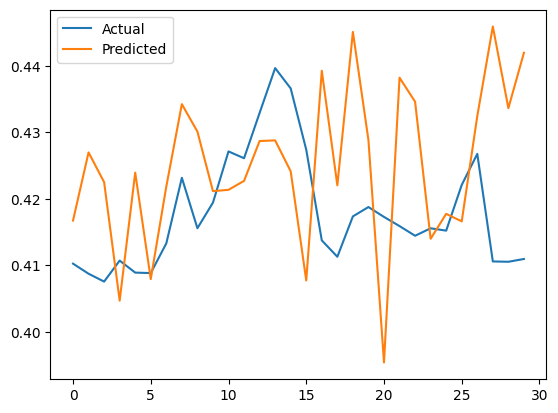

In [16]:
import matplotlib.pyplot as plt

plt.plot(y_test[0], label="Actual")
plt.plot(predictions[0], label="Predicted")
plt.legend()
plt.show()

In [17]:
import numpy as np

# Create empty array with 7 features
pred_extended = np.zeros((predictions.shape[0], predictions.shape[1], 7))

# Put predictions into gold column (assume gold was column 0 — adjust if needed)
pred_extended[:, :, 0] = predictions

# Reshape to 2D because scaler works on 2D
pred_reshaped = pred_extended.reshape(-1, 7)

# Inverse transform
pred_inverse = scaler.inverse_transform(pred_reshaped)

# Take only gold column back
predictions_actual = pred_inverse[:, 0].reshape(predictions.shape)

NameError: name 'scaler' is not defined

In [18]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

NameError: name 'MinMaxScaler' is not defined

In [20]:
import joblib

scaler = joblib.load("../data/processed/scaler.pkl")
print("Scaler loaded successfully")

Scaler loaded successfully


In [21]:
predictions = model.predict(X_test)
print(predictions.shape)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
(386, 30)


In [22]:
import numpy as np

# Create empty array with 7 features
pred_extended = np.zeros((predictions.shape[0], predictions.shape[1], 7))

# Assuming gold price was column 0 (change if different)
pred_extended[:, :, 0] = predictions

# Reshape to 2D
pred_reshaped = pred_extended.reshape(-1, 7)

# Inverse transform
pred_inverse = scaler.inverse_transform(pred_reshaped)

# Extract only gold column
predictions_actual = pred_inverse[:, 0].reshape(predictions.shape)

In [23]:
y_extended = np.zeros((y_test.shape[0], y_test.shape[1], 7))
y_extended[:, :, 0] = y_test

y_reshaped = y_extended.reshape(-1, 7)
y_inverse = scaler.inverse_transform(y_reshaped)

y_test_actual = y_inverse[:, 0].reshape(y_test.shape)

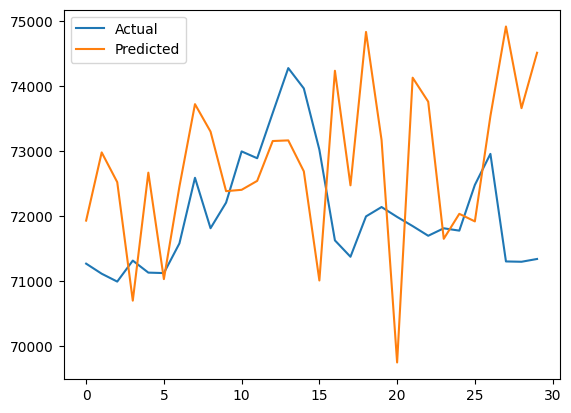

In [24]:
import matplotlib.pyplot as plt

plt.plot(y_test_actual[0], label="Actual")
plt.plot(predictions_actual[0], label="Predicted")
plt.legend()
plt.show()

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(
    y_test_actual.flatten(),
    predictions_actual.flatten()
))

print("RMSE:", rmse)

In [25]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(
    y_test_actual.flatten(),
    predictions_actual.flatten()
))

print("RMSE:", rmse)

RMSE: 13048.889305679277


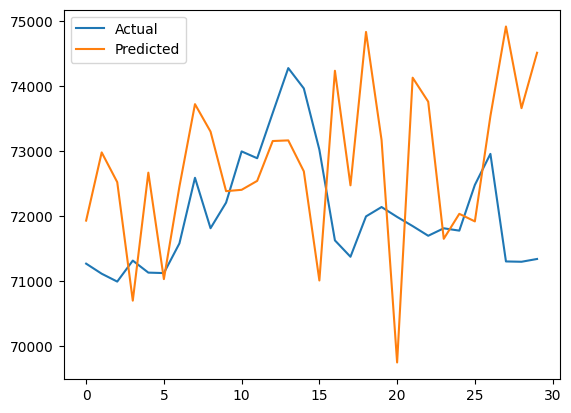

In [26]:
plt.plot(y_test_actual[0], label="Actual")
plt.plot(predictions_actual[0], label="Predicted")
plt.legend()
plt.show()

In [27]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0014 - val_loss: 0.0182
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0011 - val_loss: 0.0144
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0011 - val_loss: 0.0165
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 9.7884e-04 - val_loss: 0.0163
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 8.5391e-04 - val_loss: 0.0151
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 7.9271e-04 - val_loss: 0.0158
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - loss: 7.3120e-04 - val_loss: 0.0169
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 6.8531e-04 - val_loss: 0.0152
Epoch 9/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 6.3931e-04 - val_loss: 0.0158
Epoch 10/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 6.0848e-04 - val_loss: 0.0144
Epoch 11/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 6.2651e-04 - val_loss: 0.0214
Epoch 12/30
49/49 ━━━━━━━━━━━━

In [28]:
predictions = model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [29]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(
    y_test_actual.flatten(),
    predictions_actual.flatten()
))

print("New RMSE:", rmse)

New RMSE: 13048.889305679277


In [30]:
model.add(LSTM(64, return_sequences=True, input_shape=(7, 4)))

c:\Users\iamme\karat\karat\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ValueError: Input 0 of layer "lstm_2" is incompatible with the layer: expected ndim=3, found ndim=2. Full shape received: (None, 30)

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 4.6664e-04 - val_loss: 0.0170
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 4.2345e-04 - val_loss: 0.0145
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 3.7120e-04 - val_loss: 0.0163
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 3.7130e-04 - val_loss: 0.0174
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 4.0292e-04 - val_loss: 0.0189
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 3.9736e-04 - val_loss: 0.0190
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 3.8113e-04 - val_loss: 0.0188
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 3.8347e-04 - val_loss: 0.0192
Epoch 9/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 3.8319e-04 - val_loss: 0.0166
Epoch 10/30


KeyboardInterrupt: 

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(7, 4)))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(30))   # if you're still predicting 30 days

model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 7, 64)          │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,070 (121.37 KB)

 Trainable params: 31,070 (121.37 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/30


ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 7 and 4 for '{{node sequential_1_1/lstm_3_1/lstm_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_1_1/lstm_3_1/strided_slice_2, sequential_1_1/lstm_3_1/lstm_cell_1/Cast/ReadVariableOp)' with input shapes: [?,7], [4,256].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(None, 7), dtype=float32)
  • states=('tf.Tensor(shape=(None, 64), dtype=float32)', 'tf.Tensor(shape=(None, 64), dtype=float32)')
  • training=True

In [ ]:
import os

for root, dirs, files in os.walk("data"):
    for file in files:
        print(os.path.join(root, file))

In [ ]:
import pandas as pd

# Raw datasets
gold = pd.read_csv("../data/raw/Gold Price.csv")
usd = pd.read_csv("../data/raw/US Dollar.csv")

# Convert date column (change column name if needed)
gold['Date'] = pd.to_datetime(gold['Date'])
usd['Date'] = pd.to_datetime(usd['Date'])

print("GOLD DATASET")
print("Rows:", len(gold))
print("Start:", gold['Date'].min())
print("End:", gold['Date'].max())
print()

print("USD DATASET")
print("Rows:", len(usd))
print("Start:", usd['Date'].min())
print("End:", usd['Date'].max())

In [ ]:
import os
import pandas as pd

# Path to data folder (since notebook is inside /notebooks)
data_path = "../data"

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith(".csv"):
            file_path = os.path.join(root, file)
            print("="*60)
            print("Dataset:", file)
            
            try:
                df = pd.read_csv(file_path)
                
                # Try to detect date column automatically
                date_col = None
                for col in df.columns:
                    if "date" in col.lower():
                        date_col = col
                        break
                
                if date_col:
                    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
                    print("Rows:", len(df))
                    print("Start Date:", df[date_col].min())
                    print("End Date:", df[date_col].max())
                else:
                    print("Rows:", len(df))
                    print("⚠ No date column found")
            
            except Exception as e:
                print("Error reading file:", e)

print("="*60)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(60, 7)))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(7))  # 🔥 changed from 30 → 7

model.compile(optimizer='adam', loss='mse')

model.summary()